In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from xgboost import XGBClassifier

from src.manual_tree import *

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 1 — EDA (Titanic)

In [3]:
df.shape

(891, 12)

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [5]:
df.describe(include = "all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', 
                                                                                    ascending = False)
missing_summary

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [8]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
df['Survived'].value_counts(normalize = True).round(3) * 100

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64

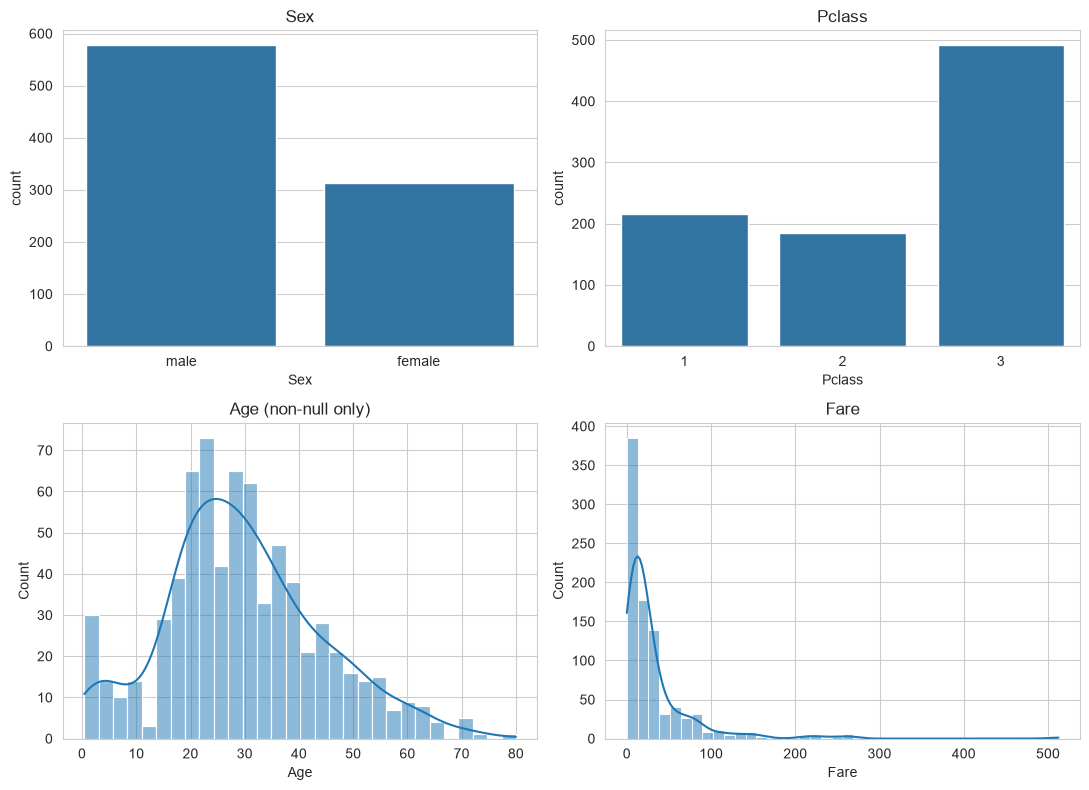

In [10]:
fig, axes = plt.subplots(2, 2, figsize = (11, 8))

sns.countplot(data = df, x = 'Sex', ax = axes[0, 0])
axes[0, 0].set_title('Sex')

sns.countplot(data = df, x = 'Pclass', ax = axes[0, 1])
axes[0, 1].set_title('Pclass')

sns.histplot(df['Age'].dropna(), bins = 30, ax = axes[1, 0], kde = True)
axes[1, 0].set_title('Age (non-null only)')

sns.histplot(df['Fare'], bins = 40, ax = axes[1, 1], kde = True)
axes[1, 1].set_title('Fare')

plt.tight_layout()
plt.show()

C:\Users\zahin\AppData\Local\Temp\ipykernel_13024\462518247.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(['Died', 'Survived'])


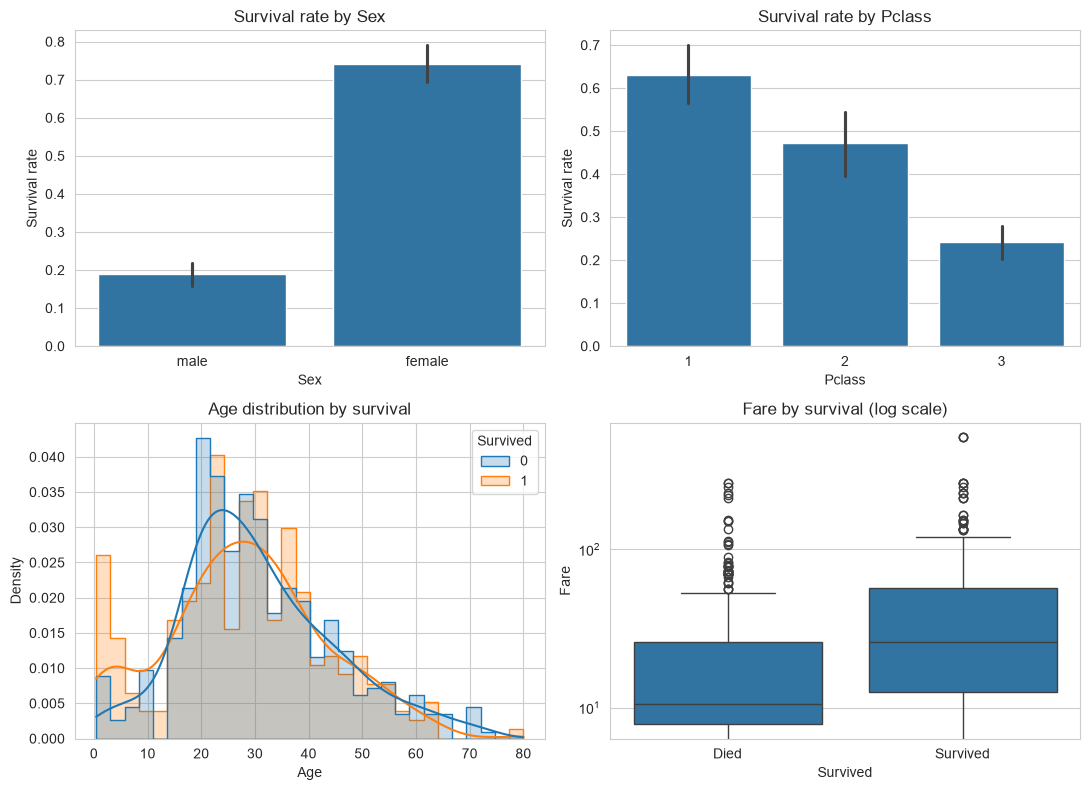

In [11]:
fig, axes = plt.subplots(2, 2, figsize = (11, 8))

sns.barplot(data = df, x = 'Sex', y = 'Survived', ax = axes[0, 0])
axes[0, 0].set_title('Survival rate by Sex')
axes[0, 0].set_ylabel('Survival rate')

sns.barplot(data = df, x = 'Pclass', y = 'Survived', ax = axes[0, 1])
axes[0, 1].set_title('Survival rate by Pclass')
axes[0, 1].set_ylabel('Survival rate')

sns.histplot(data = df, x = 'Age', hue = 'Survived', bins = 30, kde = True,
             element = 'step', stat = 'density', common_norm = False, ax = axes[1, 0])
axes[1, 0].set_title('Age distribution by survival')

sns.boxplot(data = df, x = 'Survived', y = 'Fare', ax = axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Fare by survival (log scale)')
axes[1, 1].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.show()

## Step 2 — Preprocessing

In [12]:
X = df.drop(columns = ['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df['Survived']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y,
                                                    random_state = 42)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [15]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass']

In [16]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "median"))])

categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy = "most_frequent")),
                                 ("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [17]:
preprocessor = ColumnTransformer(
    transformers = [("num", numeric_pipeline, numeric_features),
                    ("cat", categorical_pipeline, categorical_features)])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(712, 12)
(179, 12)


In [19]:
feature_names = preprocessor.get_feature_names_out()
list(feature_names)

['num__Age',
 'num__Fare',
 'num__SibSp',
 'num__Parch',
 'cat__Sex_female',
 'cat__Sex_male',
 'cat__Embarked_C',
 'cat__Embarked_Q',
 'cat__Embarked_S',
 'cat__Pclass_1',
 'cat__Pclass_2',
 'cat__Pclass_3']

## Step 3 — From-scratch decision tree split criterion (NumPy, Iris)

In [20]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [21]:
X_i = iris.data
y_i = iris.target

X_i.shape, y_i.shape

((150, 4), (150,))

In [22]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_i, y_i, test_size = 0.2, 
                                                            random_state = 42, stratify = y_i)

In [23]:
tree = DecisionTree(max_depth = 3, criterion = "gini")
tree.fit(X_train_i, y_train_i)

pred = tree.predict(X_test_i)

print("Manual Tree Accuracy:", round(accuracy_score(y_test_i, pred), 2))

Manual Tree Accuracy: 0.97


In [24]:
sk_tree = DecisionTreeClassifier(max_depth = 3, criterion = "gini", random_state = 42)
sk_tree.fit(X_train_i, y_train_i)

sk_pred = sk_tree.predict(X_test_i)

print("Sklearn Accuracy:", round(accuracy_score(y_test_i, sk_pred), 2))

Sklearn Accuracy: 0.97


In [25]:
tree_entropy = DecisionTree(max_depth = 3, criterion = "entropy")
tree_entropy.fit(X_train_i, y_train_i)

pred_entropy = tree_entropy.predict(X_test_i)

print("Manual Tree (Entropy):", round(accuracy_score(y_test_i, pred_entropy), 2))

Manual Tree (Entropy): 0.97


In [26]:
print_tree(tree.root)

├── X[2] <= 2.450
│   └── Leaf: Class 0
│   ├── X[3] <= 1.650
│   │   ├── X[2] <= 4.950
│   │   │   └── Leaf: Class 1
│   │   │   └── Leaf: Class 2
│   │   ├── X[2] <= 4.850
│   │   │   └── Leaf: Class 2
│   │   │   └── Leaf: Class 2


In [27]:
print(export_text(sk_tree, feature_names = iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



## Step 4 — Random Forest (Titanic, library)

In [28]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state = 42, class_weight = "balanced"))
])

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [29]:
param_grid = {
    "classifier__n_estimators": [100, 200], 
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
}

In [30]:
grid_search = GridSearchCV(estimator = rf_pipeline, param_grid = param_grid, scoring = "f1", 
                           cv = cv, n_jobs = -1, verbose = 2)

In [31]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parame

In [32]:
grid_search.best_params_

{'classifier__max_depth': 10,
 'classifier__max_features': 'sqrt',
 'classifier__min_samples_split': 10,
 'classifier__n_estimators': 200}

In [33]:
print("Best CV F1:", grid_search.best_score_)

Best CV F1: 0.768687209252595


In [34]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [35]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7877
Precision: 0.7246
Recall   : 0.7246
F1 Score : 0.7246
ROC-AUC  : 0.8331


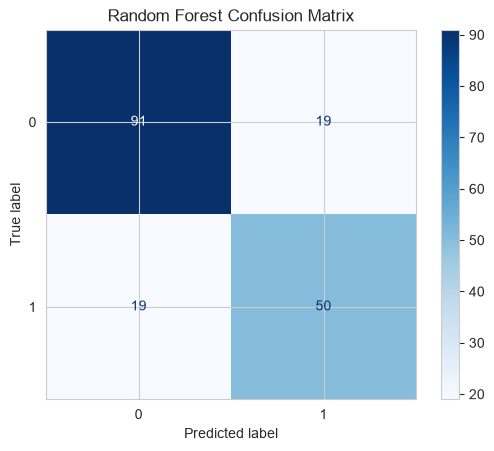

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Step 5 — XGBoost (Titanic, library)

In [39]:
xgb_pipeline = Pipeline([("preprocessor", preprocessor),
                         ("classifier", XGBClassifier(random_state = 42, eval_metric = "logloss"))])

In [40]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__subsample": [0.8, 1.0]
}

In [42]:
grid_search = GridSearchCV(estimator = xgb_pipeline, param_grid = param_grid, scoring = "f1", 
                           cv = cv, n_jobs = -1, verbose = 2)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.1, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200], 'classifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to kn

In [44]:
list(grid_search.best_params_)

['classifier__learning_rate',
 'classifier__max_depth',
 'classifier__n_estimators',
 'classifier__subsample']

In [45]:
print("Best CV F1:", grid_search.best_score_)

Best CV F1: 0.7671707572746916


In [47]:
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [48]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7933
Precision: 0.7667
Recall   : 0.6667
F1 Score : 0.7132
ROC-AUC  : 0.7923


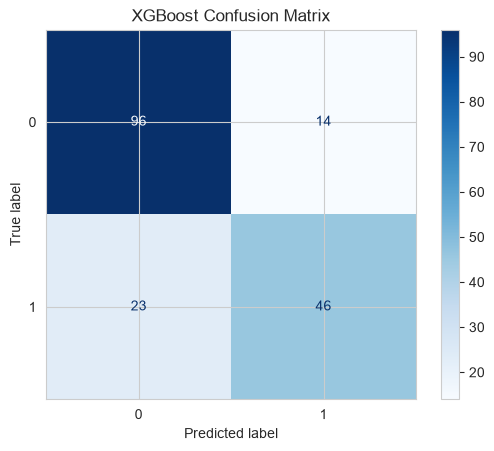

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap = "Blues")

plt.title("XGBoost Confusion Matrix")
plt.show()

## Step 6 — Feature importance

In [52]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
feature_names

array(['num__Age', 'num__Fare', 'num__SibSp', 'num__Parch',
       'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S', 'cat__Pclass_1',
       'cat__Pclass_2', 'cat__Pclass_3'], dtype=object)

### Random Forest Importance

In [53]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.named_steps["classifier"].feature_importances_
})

rf_importance = rf_importance.sort_values(by = "Importance", ascending = False)
rf_importance.head(10)

,Feature,Importance
5,cat__Sex_male,0.209470
1,num__Fare,0.196744
4,cat__Sex_female,0.193417
0,num__Age,0.161731
11,cat__Pclass_3,0.056005
2,num__SibSp,0.042525
9,cat__Pclass_1,0.041315
3,num__Parch,0.035835
10,cat__Pclass_2,0.021710
8,cat__Embarked_S,0.019779


### XGBoost Importance

In [55]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.named_steps["classifier"].feature_importances_
})

xgb_importance = xgb_importance.sort_values(by = "Importance", ascending = False)
xgb_importance.head(10)

,Feature,Importance
4,cat__Sex_female,0.361579
11,cat__Pclass_3,0.303881
9,cat__Pclass_1,0.107829
8,cat__Embarked_S,0.054872
2,num__SibSp,0.052684
1,num__Fare,0.032867
0,num__Age,0.030808
10,cat__Pclass_2,0.023352
3,num__Parch,0.017083
6,cat__Embarked_C,0.011854


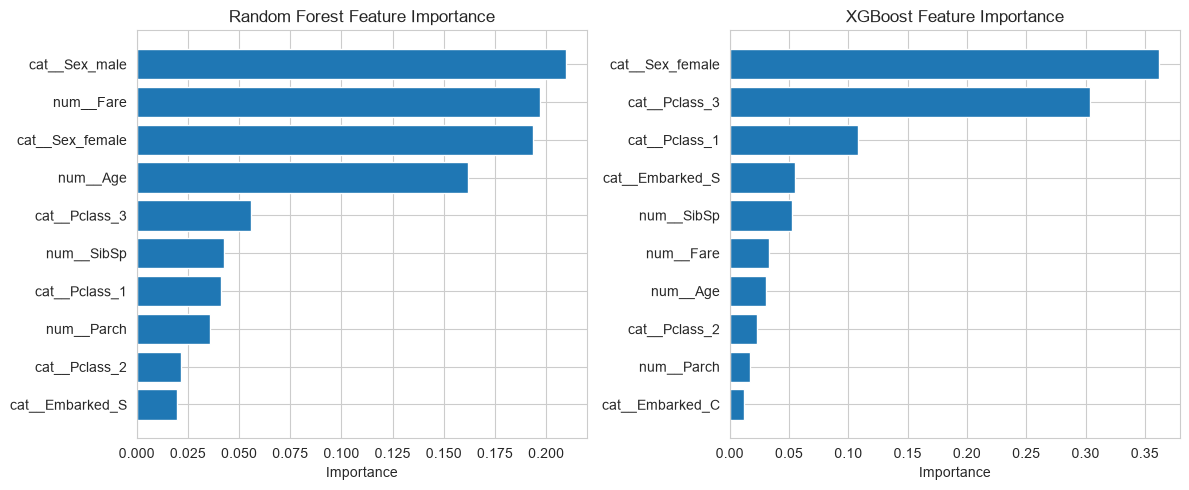

In [79]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].barh(rf_importance["Feature"][:10], rf_importance["Importance"][:10])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")

axes[1].barh(xgb_importance["Feature"][:10], xgb_importance["Importance"][:10])
axes[1].invert_yaxis()
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

### Permutation Importance — Random Forest

In [66]:
rf_perm = permutation_importance(best_rf, X_test, y_test, scoring = "f1", n_repeats = 20,
                                 random_state = 42, n_jobs = -1)

rf_perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_perm.importances_mean
})

rf_perm_df = rf_perm_df.sort_values(by = "Importance", ascending = False)
rf_perm_df.head(10)

,Feature,Importance
1,Sex,0.235196
0,Pclass,0.102696
5,Fare,0.055505
2,Age,0.046252
6,Embarked,0.018511
3,SibSp,-0.007538
4,Parch,-0.013162


### Permutation Importance — XGBoost

In [65]:
xgb_perm = permutation_importance(best_xgb, X_test, y_test, scoring = "f1", n_repeats = 20, 
                                  random_state = 42, n_jobs = -1)

7

In [69]:
xgb_perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": xgb_perm.importances_mean
})

xgb_perm_df = xgb_perm_df.sort_values(by = "Importance", ascending = False)
xgb_perm_df.head(10)

,Feature,Importance
1,Sex,0.267318
0,Pclass,0.123109
5,Fare,0.057628
2,Age,0.055025
3,SibSp,0.019313
6,Embarked,0.009542
4,Parch,-0.006873


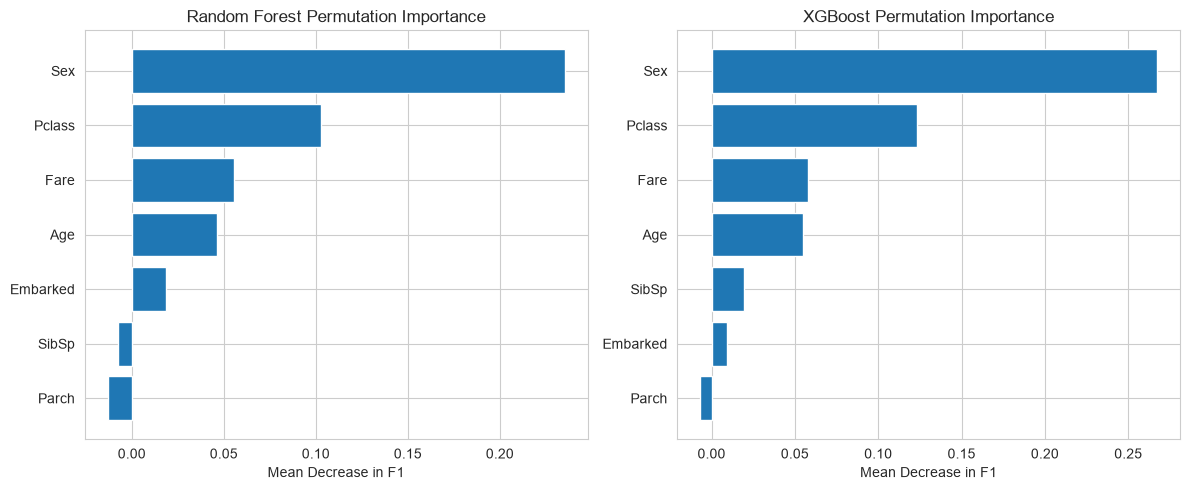

In [78]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].barh(rf_perm_df["Feature"][:10], rf_perm_df["Importance"][:10])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Permutation Importance")
axes[0].set_xlabel("Mean Decrease in F1")

axes[1].barh(xgb_perm_df["Feature"][:10], xgb_perm_df["Importance"][:10])
axes[1].invert_yaxis()
axes[1].set_title("XGBoost Permutation Importance")
axes[1].set_xlabel("Mean Decrease in F1")

plt.tight_layout()
plt.show()